# Reading a run

Everything downstream of a run reads one file: the web UI, every metric, and every
flow that rewinds a finished run.

This notebook generates its own run rather than pointing at one of yours, so it
works in a fresh clone before you have API keys. The run is real: real MCP server,
real game clock, real event log, with the model replaced by a script.

In [1]:
import os
import tempfile
from pathlib import Path

from pytest import MonkeyPatch

# These notebooks generate their own run, so nothing here reaches a provider.
# Clearing the keys makes that a fact rather than a claim: if any cell below
# tried to call a model, it would fail here rather than spend.
for _key in ("ANTHROPIC_API_KEY", "OPENAI_API_KEY", "HF_TOKEN"):
    os.environ.pop(_key, None)

SCENARIO = "warehouse_robot_recovery"
PRESET = "knobs_default"

In [2]:
from glossogen.testing import run_rounds


async def generate_run(round_count, overrides):
    """Run the real round loop with the model replaced by a script.

    Every part of the platform is real here: the MCP server, the tool dispatch,
    the game clock, the world and the event logger. Only the LLM is scripted, so
    this costs nothing, needs no key, and gives the same answer every time.
    """
    with MonkeyPatch.context() as patch:
        return await run_rounds(
            scenario_name=SCENARIO,
            preset_name=PRESET,
            round_count=round_count,
            overrides=overrides,
            tmp_path=Path(tempfile.mkdtemp()),
            monkeypatch=patch,
        )


result = await generate_run(round_count=4, overrides={})
print(f"{len(result.events)} events at {result.log_path}")

[08/17/26 15:06:27] INFO     Registered scenario MCP tool: perform_recovery                        ]8;id=18528;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/runtime/mcp_tools.py\mcp_tools.py]8;;\:]8;id=18529;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/runtime/mcp_tools.py#600\600]8;;\

                    INFO     MCP server mounted for in-process dispatch                ]8;id=18536;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/autonomous_supervisor.py\autonomous_supervisor.py]8;;\:]8;id=18537;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/autonomous_supervisor.py#115\115]8;;\

                    INFO     Game clock started. Round 1/4, injections delivered.                 ]8;id=18544;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/runtime/game_clock.py\game_clock.py]8;;\:]8;id=18545;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/runtime/game_clock.py#210\210]8;;\

                    INFO     Starting Pydantic AI agent floor_associate (Floor Associate) ]8;id=18552;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/runners/pydantic_ai_runner.py\pydantic_ai_runner.py]8;;\:]8;id=18553;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/runners/pydantic_ai_runner.py#260\260]8;;\
                             max_turns=30 provider=anthropic                                                       
                             model=scripted::floor_associate                                                       

                    INFO     Launched agent floor_associate (Floor Associate)          ]8;id=18559;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/autonomous_supervisor.py\autonomous_supervisor.py]8;;\:]8;id=18560;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/autonomous_supervisor.py#497\497]8;;\

...

                    INFO     Stopping world simulation                                 ]8;id=20859;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/autonomous_supervisor.py\autonomous_supervisor.py]8;;\:]8;id=20860;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/autonomous_supervisor.py#560\560]8;;\

                    INFO     Stopping MCP server                                       ]8;id=20866;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/autonomous_supervisor.py\autonomous_supervisor.py]8;;\:]8;id=20867;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/autonomous_supervisor.py#571\571]8;;\

                    INFO     Simulation complete. Total messages: 9, total cost:       ]8;id=20873;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/autonomous_supervisor.py\autonomous_supervisor.py]8;;\:]8;id=20874;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/autonomous_supervisor.py#592\592]8;;\
                             $0.0000                                                                               

                    INFO     Event log closed:                                                   ]8;id=20881;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/event_logger.py\event_logger.py]8;;\:]8;id=20882;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/event_logger.py#70\70]8;;\
                             /var/folders/b_/5cy1dmx94wn81w9y4x6x8zc40000gn/T/tmprohzneov/smoke.                   
                             jsonl                                                                                 

344 events at /var/folders/b_/5cy1dmx94wn81w9y4x6x8zc40000gn/T/tmprohzneov/smoke.jsonl


## What a run is made of

One line per event, appended and never rewritten. That is what makes a byte offset
into this file a stable address, and it is why a finished run can be replayed from
any round.

In [3]:
import collections

kinds = collections.Counter(event["event_type"] for event in result.events)
for kind, count in kinds.most_common():
    print(f"{count:5}  {kind}")

  132  llm_response_received
   66  tool_call_invoked
   66  tool_result_received
   24  injection_delivered
   15  world_event_delivered
    9  message_sent
    4  round_advanced
    4  warehouse_case_started
    4  round_ended
    4  round_result_recorded
    4  postmortem_started
    4  postmortem_ended
    3  agent_registered
    3  agent_connected
    1  simulation_started
    1  simulation_ended


Most of a run is the agents thinking rather than speaking:
`llm_response_received` and `tool_call_invoked` dwarf `message_sent`. An agent
spends most of its turns reading notifications and calling tools.

The events that carry the scenario are the other two. `injection_delivered` is the
scenario telling an agent what happened this round; `world_event_delivered` is the
world answering what an agent did.

## Loading it the way the platform does

`load_events` parses each line into a typed event and backfills `round_number` on
older logs, so downstream code can read that field on any event.

In [4]:
from glossogen.evaluation.log_reader import load_events

events = await load_events(log_path=result.log_path)
print(f"{len(events)} typed events")
print(f"rounds recorded: {len({e.round_number for e in events if e.round_number})}")

                    INFO     Loaded 344 events from                                                ]8;id=20889;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/evaluation/log_reader.py\log_reader.py]8;;\:]8;id=20890;file:///Users/nsander/workspace/schmidt-poc/src/glossogen/evaluation/log_reader.py#54\54]8;;\
                             /var/folders/b_/5cy1dmx94wn81w9y4x6x8zc40000gn/T/tmprohzneov/smoke.js                 
                             onl                                                                                   

344 typed events
rounds recorded: 4


## One row per message

The primary channel is the one the throughput and language metrics read, and the
scenario declares it rather than the analysis guessing. Ask the scenario, so this
cell works unchanged on a scenario with two competing teams.

In [5]:
import pandas as pd

primary = {channel.channel_id for channel in result.scenario.get_primary_channels()}
print(f"primary channel(s): {sorted(primary)}")

rows = [
    {
        "round": event["message"]["round_number"],
        "sender": event["message"]["sender_agent_id"],
        "channel": event["message"]["channel_id"],
        "chars": len(event["message"]["text"]),
        "text": event["message"]["text"],
    }
    for event in result.of_type(event_type="message_sent")
    if event["message"]["channel_id"] in primary
]
messages = pd.DataFrame(rows)
messages

primary channel(s): ['radio']


,round,sender,channel,chars,text
0,1,floor_associate,radio,25,floor_associate reporting
1,1,robotics_engineer,radio,27,robotics_engineer reporting
2,1,fleet_safety_coordinator,radio,34,fleet_safety_coordinator reporting
3,1,floor_associate,radio,25,floor_associate reporting
4,1,robotics_engineer,radio,27,robotics_engineer reporting
5,1,fleet_safety_coordinator,radio,34,fleet_safety_coordinator reporting
6,1,floor_associate,radio,25,floor_associate reporting
7,1,robotics_engineer,radio,27,robotics_engineer reporting
8,1,fleet_safety_coordinator,radio,34,fleet_safety_coordinator reporting


## Characters per round

In this scenario a character is a cost: the agents spend a budget by talking.
`mean_chars_per_round` is this number, computed here by hand.

       chars  messages
round                 
1        258         9

mean chars/round: 258.0


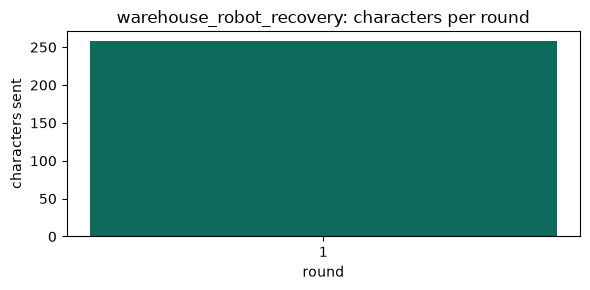

In [6]:
import matplotlib.pyplot as plt

per_round = messages.groupby("round")["chars"].agg(["sum", "count"])
per_round.columns = ["chars", "messages"]
print(per_round)
print(f"\nmean chars/round: {per_round['chars'].mean():.1f}")

figure, axis = plt.subplots(figsize=(6, 3))
axis.bar(per_round.index, per_round["chars"], color="#0e6b5c")
axis.set_xlabel("round")
axis.set_ylabel("characters sent")
axis.set_title(f"{SCENARIO}: characters per round")
axis.set_xticks(list(per_round.index))
figure.tight_layout()

The scripted agents send the same short message every round, so this plot is
flat. Against a real run it is not, and the shape of it is the finding: agents
under budget pressure send less per round as they converge on a shorter code.

## Round verdicts

`judge_round_result` is a required hook, and the game clock writes what it returns
into `round_result_recorded`. That event is the only thing `round_success` reads,
which is why the metric works on any scenario without knowing anything about
robots.

In [7]:
verdicts = result.of_type(event_type="round_result_recorded")
for verdict in verdicts:
    print(f"round {verdict['round_number']}: success={verdict['success']}")

passed = sum(1 for verdict in verdicts if verdict["success"])
print(f"\nround_success would report {passed}/{len(verdicts)}")

round 1: success=False
round 2: success=False
round 3: success=False
round 4: success=False

round_success would report 0/4


Next: [02_score_a_run.ipynb](02_score_a_run.ipynb) runs the real metric layer over
a run instead of computing numbers by hand.